# ECE143 WI26 Project
## Student Loan Debt vs. Career Outcomes  
### Group 20
#### Nathan Chao, Mark Sui, Aneesh Sreekanth, Haifan Zhao, Zixuan Chen 
#### University of California San Diego

---

## 1. Import and load the data

In [1]:
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, linregress
from IPython.display import display

warnings.filterwarnings("ignore")

data_dir = Path("project_datasets/preprocessed_datasets")
raw_dir = Path("project_datasets")

In [2]:
adult = pd.read_csv(data_dir / "cleaned_adult.csv",
    usecols=["age", "education", "hours_per_week", "income", "income_over50k"])

pums = pd.read_csv(data_dir / "cleaned_pums.csv",
    usecols=["education_level", "annual_income", "age", "person_weight",
             "field_of_degree", "is_recent_grad", "sex", "state"])

state_summary = pd.read_csv(data_dir / "cleaned_state_summary.csv",
    usecols=["state", "annual_cost_of_living", "avg_annual_wage",
             "real_wage_gap_bls", "monster_job_count",
             "is_high_cost_state", "monster_median_salary",
             "median_family_income", "col_index"])

cost_state = pd.read_csv(data_dir / "cleaned_cost_state.csv",
    usecols=["state", "housing_cost", "food_cost", "transportation_cost",
             "healthcare_cost", "taxes", "annual_cost_of_living"])

monster = pd.read_csv(data_dir / "cleaned_monster.csv",
    usecols=["sector", "salary_mid", "salary_available"])

migration = pd.read_csv(data_dir / "cleaned_migration.csv",
    usecols=["origin_state", "dest_state", "n_individuals", "avg_agi"])

bls_wages = pd.read_csv(data_dir / "cleaned_bls_wages.csv")
occ_lookup = pd.read_csv(raw_dir / "wm.occupation.csv",
    usecols=["occupation_code", "occupation_text"])

print("Finished loading.")

Finished loading.


## 2. Overview

- **adult** – demographic and income information for individuals  
- **pums** – large microdata sample with age, education, income, field of degree, and migration variables  
- **state_summary** – state-level statistics such as wages, cost of living, and job counts  
- **cost_state** – breakdown of living costs by state (housing, food, taxes, etc.)  
- **monster** – job salary information by sector from job postings  
- **migration** – number of people moving between U.S. states with average income  
- **bls_wages** – Bureau of Labor Statistics occupation-level wage data by state

In [3]:
datasets = {
    "adult": adult,
    "pums": pums,
    "state_summary": state_summary,
    "cost_state": cost_state,
    "monster": monster,
    "migration": migration,
    "bls_wages": bls_wages,
}

overview = pd.DataFrame({
    "dataset": datasets.keys(),
    "rows": [df.shape[0] for df in datasets.values()],
    "columns": [df.shape[1] for df in datasets.values()],
})

display(overview)

,dataset,rows,columns
0,adult,32561,5
1,pums,1360855,8
2,state_summary,51,9
3,cost_state,51,7
4,monster,19561,3
5,migration,5094,4
6,bls_wages,7874,10


In [4]:
display(adult.head())
display(state_summary.head())

,age,education,hours_per_week,income,income_over50k
0,90,HS-grad,40,<=50K,False
1,82,HS-grad,18,<=50K,False
2,66,Some-college,40,<=50K,False
3,54,7th-8th,40,<=50K,False
4,41,Some-college,40,<=50K,False


,state,annual_cost_of_living,median_family_income,col_index,avg_annual_wage,monster_median_salary,monster_job_count,real_wage_gap_bls,is_high_cost_state
0,AK,40437.789724,79776.171875,1.0858,57795.0,NaN,NaN,17357.210276,True
1,AL,35533.209367,73010.414062,0.9541,44567.0,70000.0,20.0,9033.790633,False
2,AR,33428.470080,58720.074219,0.8976,41576.0,65000.0,9.0,8147.529920,False
3,AZ,38124.817840,42365.816406,1.0237,47879.0,43680.0,12.0,9754.182160,True
4,CA,47925.746007,122820.718750,1.2868,55884.0,50960.0,244.0,7958.253993,True


## 3. Education and income

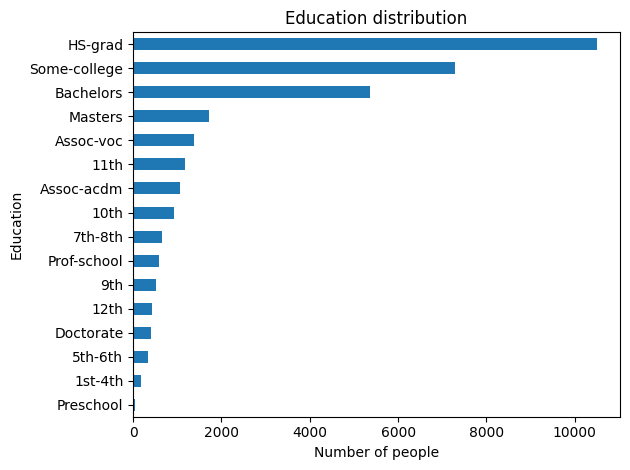

In [5]:
education_counts = adult["education"].value_counts().sort_values()
education_counts.plot(kind="barh")
plt.title("Education distribution") #in the Adult dataset
plt.xlabel("Number of people")
plt.ylabel("Education")
plt.tight_layout()
plt.show()

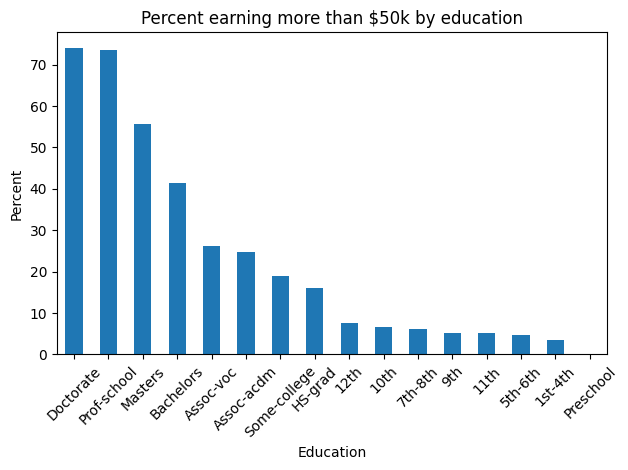

In [6]:
income_rate = adult.groupby("education")["income_over50k"].mean() * 100
income_rate = income_rate.sort_values(ascending=False)
income_rate.plot(kind="bar")

plt.title("Percent earning more than $50k by education")
plt.xlabel("Education")
plt.ylabel("Percent")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

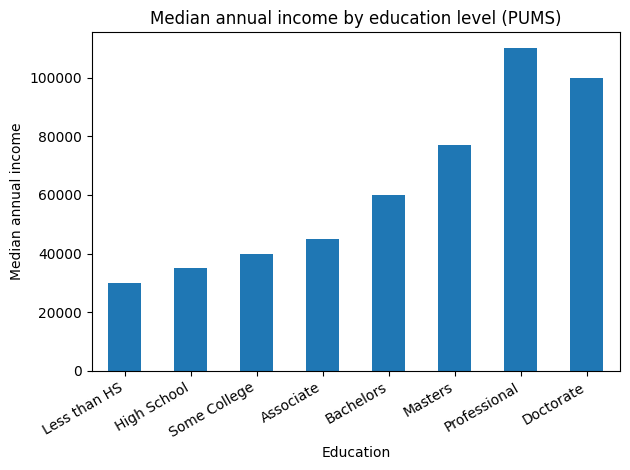

In [7]:
edu_order = ["Less than HS", "High School", "Some College", "Associate", "Bachelors", "Masters", "Professional", "Doctorate"]
pums_income = pums[pums["annual_income"] > 0].copy()
pums_income["education_level"] = pd.Categorical(pums_income["education_level"], categories=edu_order, ordered=True)
median_income = pums_income.groupby("education_level", observed=True)["annual_income"].median().dropna().sort_index()
median_income.plot(kind="bar")

plt.title("Median annual income by education level (PUMS)")
plt.xlabel("Education")
plt.ylabel("Median annual income")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

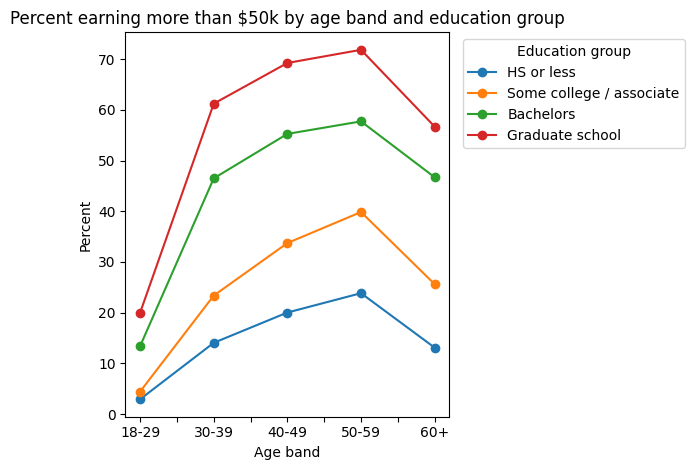

In [8]:
education_map = {"Preschool":"HS or less","1st-4th":"HS or less","5th-6th":"HS or less","7th-8th":"HS or less","9th":"HS or less","10th":"HS or less","11th":"HS or less","12th":"HS or less","HS-grad":"HS or less","Some-college":"Some college / associate","Assoc-acdm":"Some college / associate","Assoc-voc":"Some college / associate","Bachelors":"Bachelors","Masters":"Graduate school","Prof-school":"Graduate school","Doctorate":"Graduate school"}
education_order = ["HS or less", "Some college / associate", "Bachelors", "Graduate school"]
adult_age = adult.copy()
adult_age["education_group"] = adult_age["education"].map(education_map)
adult_age = adult_age.dropna(subset=["education_group"])
adult_age["age_band"] = pd.cut(adult_age["age"], bins=[17,29,39,49,59,90], labels=["18-29","30-39","40-49","50-59","60+"])
age_income = adult_age.groupby(["age_band","education_group"])["income_over50k"].mean().reset_index()
age_income_pivot = age_income.pivot(index="age_band", columns="education_group", values="income_over50k") * 100
age_income_pivot = age_income_pivot[education_order]
age_income_pivot.plot(marker="o")

plt.title("Percent earning more than $50k by age band and education group")
plt.xlabel("Age band")
plt.ylabel("Percent")
plt.legend(title="Education group", bbox_to_anchor=(1.02,1), loc="upper left")
plt.tight_layout()
plt.show()

### Income by field of degree (recent graduates)

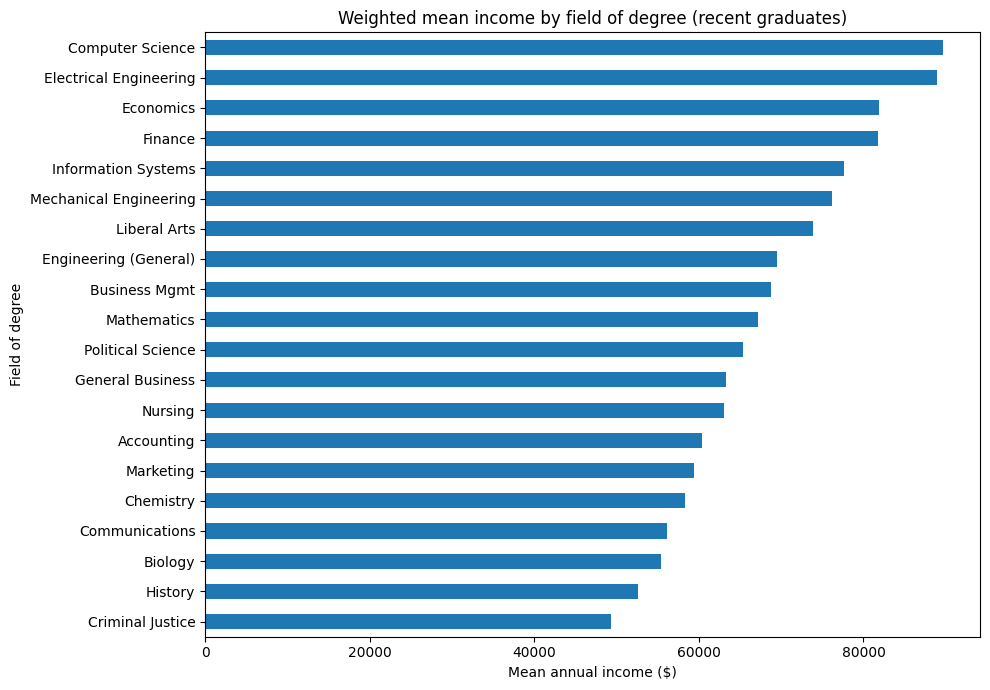

In [9]:
fod_map = {
    6203: "Accounting", 5200: "Psychology", 6107: "Nursing",
    6200: "General Business", 3600: "Biology", 6201: "Business Mgmt",
    2102: "Computer Science", 2300: "English", 3301: "Criminal Justice",
    1901: "Communications", 2304: "English Literature", 6206: "Marketing",
    5506: "Political Science", 6207: "Finance", 5301: "Physical Sciences",
    5501: "Economics", 2408: "Electrical Engineering", 6402: "History",
    2414: "Mechanical Engineering", 2401: "Liberal Arts",
    2500: "Engineering (General)", 1100: "Agriculture",
    5003: "Chemistry", 2105: "Information Systems",
    3700: "Mathematics", 6100: "Health Administration",
}

recent_grads = pums[(pums["is_recent_grad"] == True) & (pums["annual_income"] > 0)].copy()
recent_grads["field_name"] = recent_grads["field_of_degree"].map(fod_map)
recent_grads = recent_grads.dropna(subset=["field_name"])

field_income = (
    recent_grads.groupby("field_name")
    .apply(lambda g: np.average(g["annual_income"], weights=g["person_weight"]))
    .sort_values(ascending=True)
    .tail(20)
)

field_income.plot(kind="barh", figsize=(10, 7))
plt.title("Weighted mean income by field of degree (recent graduates)")
plt.xlabel("Mean annual income ($)")
plt.ylabel("Field of degree")
plt.tight_layout()
plt.show()

### Gender pay gap by education level

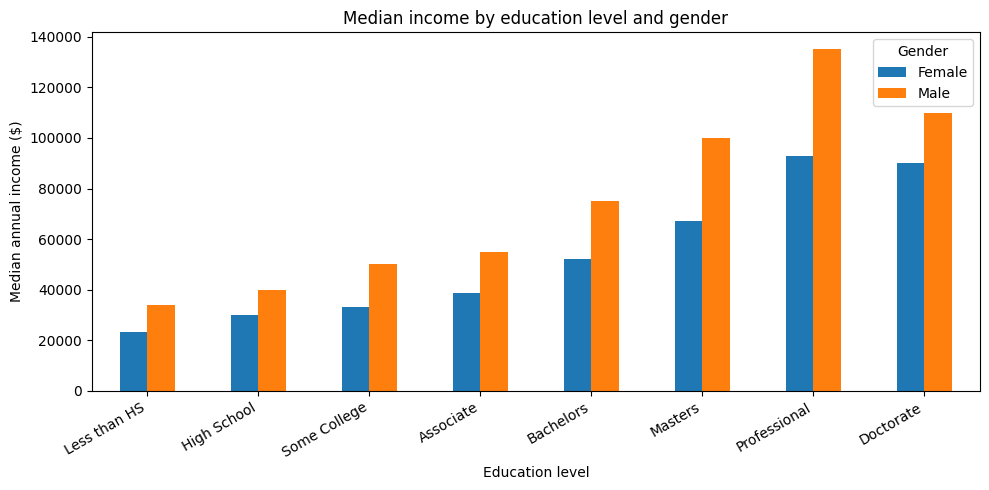

In [10]:
edu_order = ["Less than HS", "High School", "Some College", "Associate", "Bachelors", "Masters", "Professional", "Doctorate"]
pums_pos = pums[pums["annual_income"] > 0].copy()
pums_pos["education_level"] = pd.Categorical(pums_pos["education_level"], categories=edu_order, ordered=True)

gender_income = (
    pums_pos.groupby(["education_level", "sex"], observed=True)["annual_income"]
    .median()
    .unstack()
)

gender_income.plot(kind="bar", figsize=(10, 5))
plt.title("Median income by education level and gender")
plt.xlabel("Education level")
plt.ylabel("Median annual income ($)")
plt.xticks(rotation=30, ha="right")
plt.legend(title="Gender")
plt.tight_layout()
plt.show()

## 4. Student Loan Debt and Return on Investment

Average student debt by education level based on published national statistics from the Federal Reserve and Education Data Initiative.

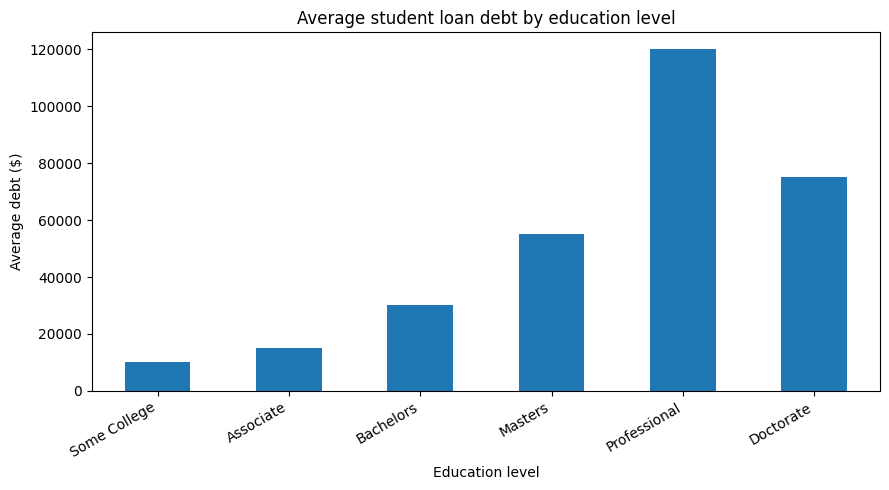

In [11]:
edu_order = ["Less than HS", "High School", "Some College", "Associate", "Bachelors", "Masters", "Professional", "Doctorate"]

debt_by_education = pd.DataFrame({
    "education_level": edu_order,
    "avg_student_debt": [0, 0, 10000, 15000, 30000, 55000, 120000, 75000],
    "avg_monthly_payment": [0, 0, 100, 150, 300, 550, 1200, 750],
})

pums_income_pos = pums[pums["annual_income"] > 0].copy()
pums_income_pos["education_level"] = pd.Categorical(
    pums_income_pos["education_level"], categories=edu_order, ordered=True
)
median_income = (
    pums_income_pos.groupby("education_level", observed=True)["annual_income"]
    .median().reset_index()
)
median_income.columns = ["education_level", "median_income"]

debt_income = debt_by_education.merge(median_income, on="education_level")
debt_income["education_level"] = pd.Categorical(
    debt_income["education_level"], categories=edu_order, ordered=True
)
debt_income = debt_income.sort_values("education_level")

debt_income[debt_income["avg_student_debt"] > 0].plot(
    x="education_level", y="avg_student_debt", kind="bar", legend=False, figsize=(9, 5)
)
plt.title("Average student loan debt by education level")
plt.xlabel("Education level")
plt.ylabel("Average debt ($)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

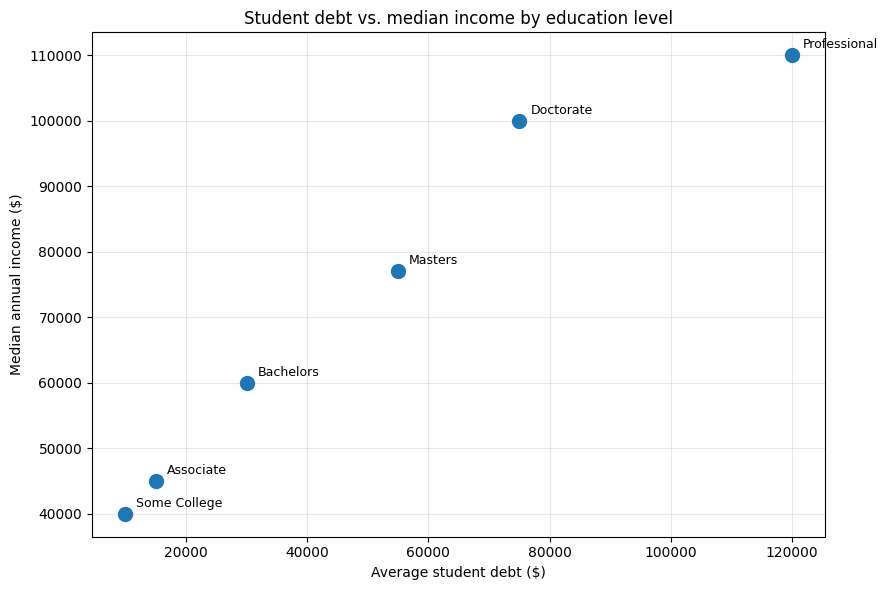

In [12]:
# Scatter plot: Debt vs. Median Income by education level
fig, ax = plt.subplots(figsize=(9, 6))
has_debt = debt_income[debt_income["avg_student_debt"] > 0]
ax.scatter(has_debt["avg_student_debt"], has_debt["median_income"], s=100, zorder=5)

for _, row in has_debt.iterrows():
    ax.annotate(row["education_level"],
                (row["avg_student_debt"], row["median_income"]),
                textcoords="offset points", xytext=(8, 5), fontsize=9)

ax.set_xlabel("Average student debt ($)")
ax.set_ylabel("Median annual income ($)")
ax.set_title("Student debt vs. median income by education level")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

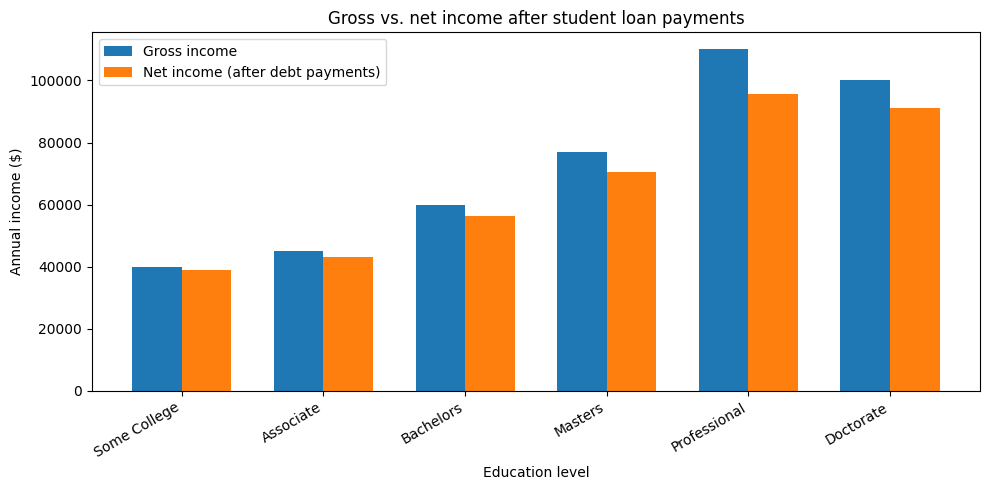

In [13]:
# Grouped bar: Gross income vs. net-of-debt income
debt_income["annual_debt_payment"] = debt_income["avg_monthly_payment"] * 12
debt_income["net_income"] = debt_income["median_income"] - debt_income["annual_debt_payment"]

has_debt = debt_income[debt_income["avg_student_debt"] > 0].copy()
x = np.arange(len(has_debt))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - width/2, has_debt["median_income"], width, label="Gross income")
ax.bar(x + width/2, has_debt["net_income"], width, label="Net income (after debt payments)")

ax.set_xlabel("Education level")
ax.set_ylabel("Annual income ($)")
ax.set_title("Gross vs. net income after student loan payments")
ax.set_xticks(x)
ax.set_xticklabels(has_debt["education_level"], rotation=30, ha="right")
ax.legend()
plt.tight_layout()
plt.show()

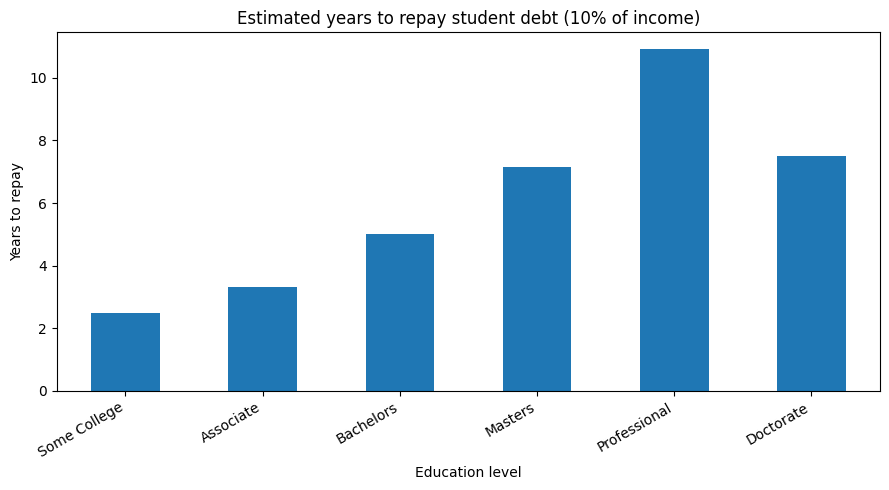

In [14]:
# Years to repay debt (assuming 10% of income)
has_debt = debt_income[debt_income["avg_student_debt"] > 0].copy()
has_debt["years_to_repay"] = has_debt["avg_student_debt"] / (has_debt["median_income"] * 0.10)

has_debt.plot(x="education_level", y="years_to_repay", kind="bar", legend=False, figsize=(9, 5))
plt.title("Estimated years to repay student debt (10% of income)")
plt.xlabel("Education level")
plt.ylabel("Years to repay")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

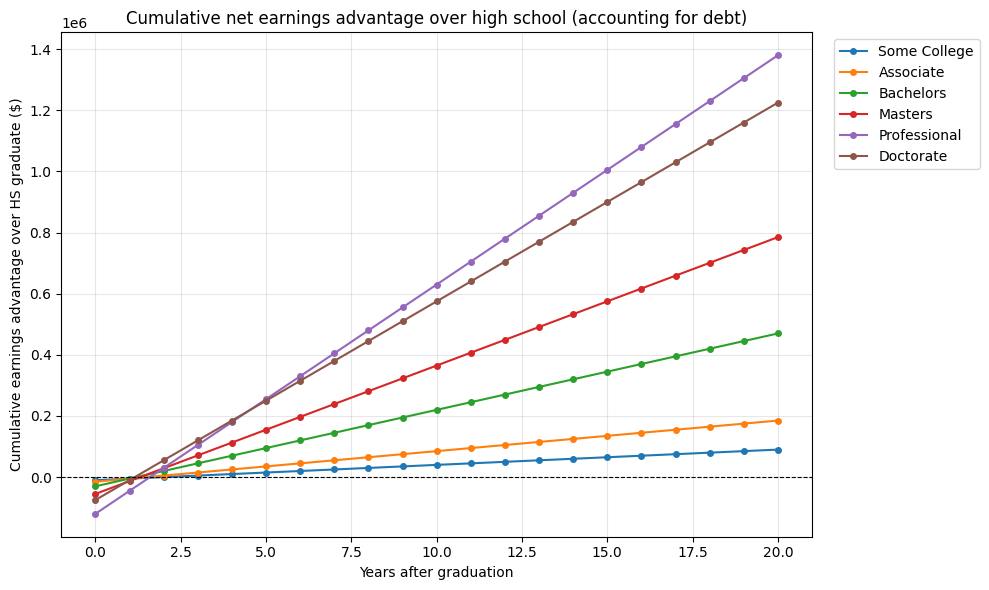

In [15]:
# Cumulative earnings advantage over 20 years (degree vs. high school, accounting for debt)
hs_income = debt_income.loc[debt_income["education_level"] == "High School", "median_income"].values[0]
years = np.arange(0, 21)

fig, ax = plt.subplots(figsize=(10, 6))
for _, row in debt_income[debt_income["avg_student_debt"] > 0].iterrows():
    cumulative = -row["avg_student_debt"] + (row["median_income"] - hs_income) * years
    ax.plot(years, cumulative, marker="o", markersize=4, label=row["education_level"])

ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_xlabel("Years after graduation")
ax.set_ylabel("Cumulative earnings advantage over HS graduate ($)")
ax.set_title("Cumulative net earnings advantage over high school (accounting for debt)")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Analysis:** This chart shows the long-term financial payoff of each degree relative to a high school graduate, starting from the moment of graduation (where debt puts degree holders in the negative). Key observations:
- **Bachelors** breaks even within ~3 years and accumulates the most consistent advantage over time, making it the strongest ROI pick.
- **Professional degrees** start with a steep \$120k deficit but have the highest slope, overtaking all others by ~year 8–10.
- **Some College and Associate** degrees break even fastest (1–2 years) due to low debt, but their long-term advantage is modest.
- **Doctorate** holders recover faster than Professional degree holders due to lower debt, but their income ceiling is also lower.

## 5. Geography and cost of living

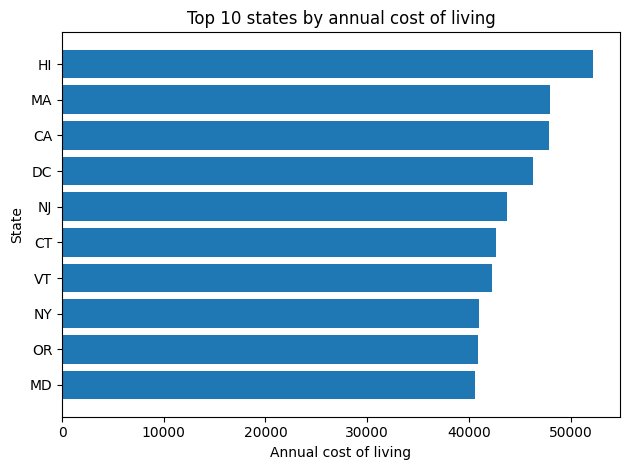

In [16]:
top_cost = cost_state.sort_values("annual_cost_of_living", ascending=False).head(10)

plt.barh(top_cost["state"], top_cost["annual_cost_of_living"])
plt.title("Top 10 states by annual cost of living")
plt.xlabel("Annual cost of living")
plt.ylabel("State")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

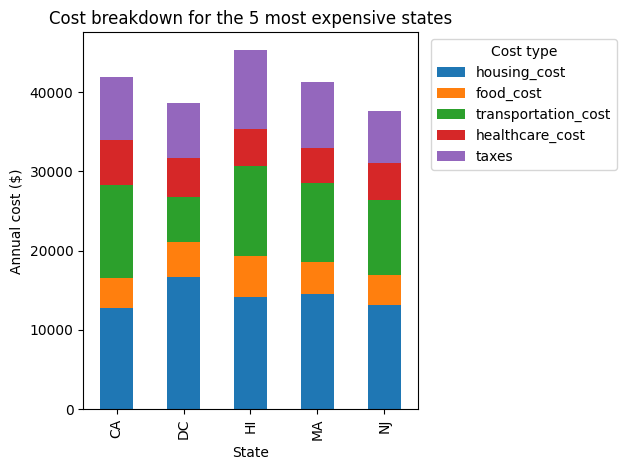

In [17]:
selected_states = cost_state.sort_values("annual_cost_of_living", ascending=False).head(5)["state"]
cost_breakdown = cost_state[cost_state["state"].isin(selected_states)].set_index("state")[["housing_cost","food_cost","transportation_cost","healthcare_cost","taxes"]]
cost_breakdown.plot(kind="bar", stacked=True)

plt.title("Cost breakdown for the 5 most expensive states")
plt.xlabel("State")
plt.ylabel("Annual cost ($)")
plt.legend(title="Cost type", bbox_to_anchor=(1.02,1), loc="upper left")
plt.tight_layout()
plt.show()

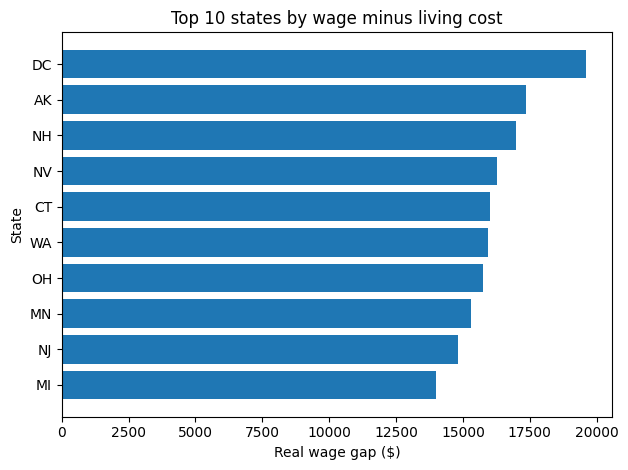

In [18]:
top_gap = state_summary.sort_values("real_wage_gap_bls", ascending=False).head(10)

plt.barh(top_gap["state"], top_gap["real_wage_gap_bls"])
plt.title("Top 10 states by wage minus living cost")
plt.xlabel("Real wage gap ($)")
plt.ylabel("State")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

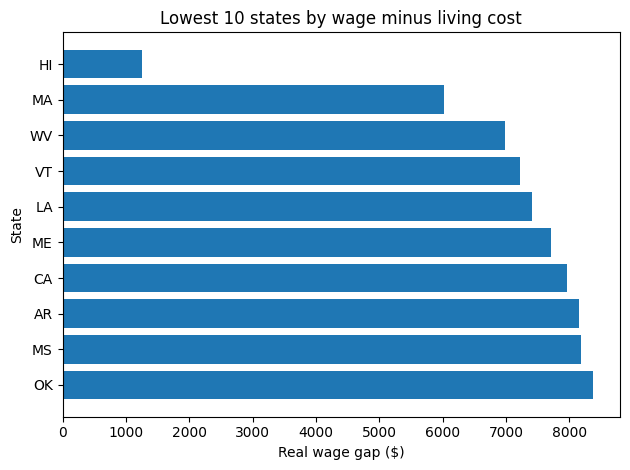

In [19]:
bottom_gap = state_summary.sort_values("real_wage_gap_bls", ascending=True).head(10)

plt.barh(bottom_gap["state"], bottom_gap["real_wage_gap_bls"])
plt.title("Lowest 10 states by wage minus living cost")
plt.xlabel("Real wage gap ($)")
plt.ylabel("State")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

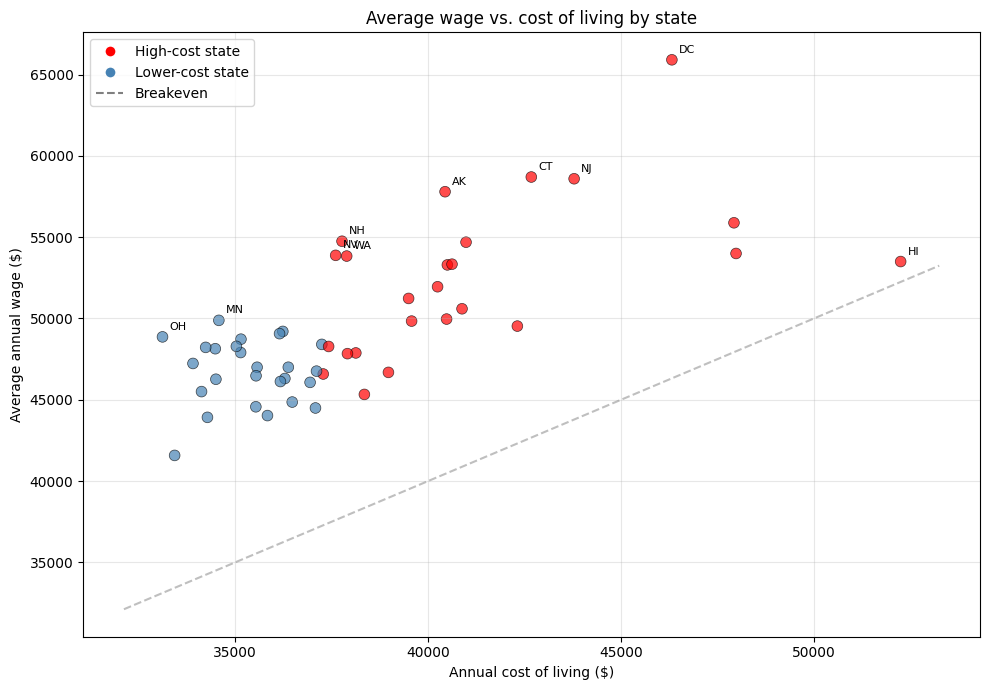

In [20]:
# Scatter: Average wage vs. cost of living by state
fig, ax = plt.subplots(figsize=(10, 7))

colors = state_summary["is_high_cost_state"].map({True: "red", False: "steelblue"})
ax.scatter(state_summary["annual_cost_of_living"], state_summary["avg_annual_wage"],
           c=colors, s=60, alpha=0.7, edgecolors="black", linewidth=0.5)

# Breakeven line (wage = cost of living)
lims = [state_summary["annual_cost_of_living"].min() - 1000,
        state_summary["annual_cost_of_living"].max() + 1000]
ax.plot(lims, lims, "--", color="gray", alpha=0.5, label="Breakeven (wage = COL)")

# Label outlier states
for _, row in state_summary.iterrows():
    if row["real_wage_gap_bls"] > 15000 or row["real_wage_gap_bls"] < 3000 or row["avg_annual_wage"] > 58000:
        ax.annotate(row["state"], (row["annual_cost_of_living"], row["avg_annual_wage"]),
                    textcoords="offset points", xytext=(5, 5), fontsize=8)

ax.set_xlabel("Annual cost of living ($)")
ax.set_ylabel("Average annual wage ($)")
ax.set_title("Average wage vs. cost of living by state")
ax.legend(loc="upper left")

from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker="o", color="w", markerfacecolor="red", markersize=8, label="High-cost state"),
    Line2D([0], [0], marker="o", color="w", markerfacecolor="steelblue", markersize=8, label="Lower-cost state"),
    Line2D([0], [0], linestyle="--", color="gray", label="Breakeven"),
]
ax.legend(handles=legend_elements, loc="upper left")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Analysis:** Every state sits above the breakeven diagonal, meaning average wages exceed cost of living everywhere — but the margin varies widely. States like DC, WA, and AK sit farthest above the line, offering the largest real wage gaps. High-cost states (red) cluster in the upper right: they pay more but cost more, and several (e.g., HI, CA) barely clear the breakeven line. For a job seeker, the vertical distance above the diagonal is what matters — that gap is your actual disposable income.

## 6. Job Market

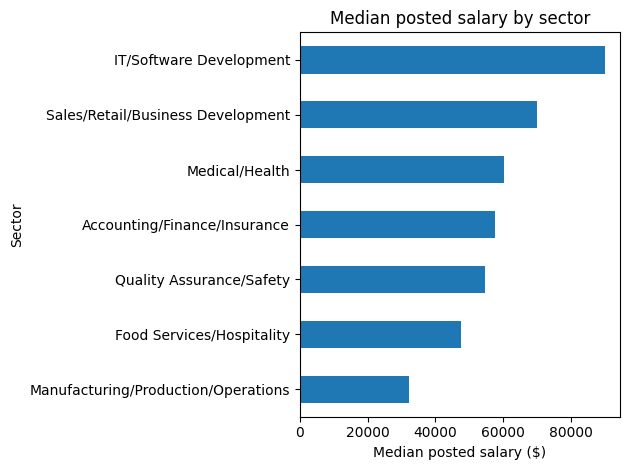

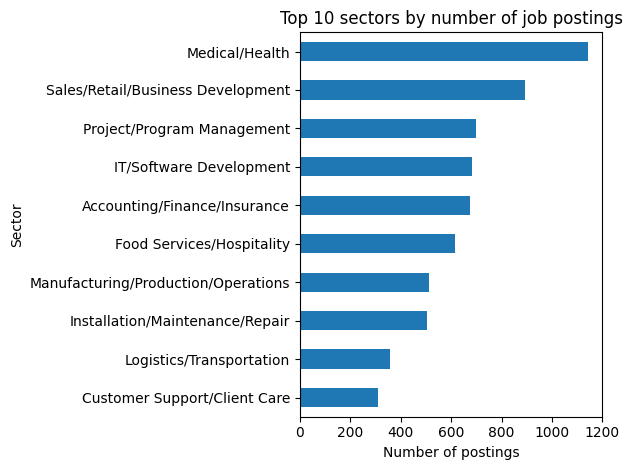

In [39]:
job_level_values = [
    "Entry Level",
    "Experienced (Non-Manager)",
    "Manager (Manager/Supervisor of Staff)"
]

monster_sector = monster.copy()

monster_sector["sector"] = monster_sector["sector"].str.strip()

monster_sector = monster_sector[
    monster_sector["sector"].notna() &
    ~monster_sector["sector"].isin(job_level_values)
]

sector_salary = (
    monster_sector[monster_sector["salary_available"] == True]
    .dropna(subset=["salary_mid", "sector"])
    .query("10000 < salary_mid < 250000")
    .groupby("sector")["salary_mid"]
    .agg(["median", "count"])
)

sector_salary = sector_salary[sector_salary["count"] >= 40].sort_values("median").tail(10)

sector_salary["median"].plot(kind="barh")
plt.title("Median posted salary by sector")
plt.xlabel("Median posted salary ($)")
plt.ylabel("Sector")
plt.tight_layout()
plt.show()

sector_counts = (
    monster_sector["sector"]
    .dropna()
    .value_counts()
    .head(10)
    .sort_values()
)

sector_counts.plot(kind="barh")
plt.title("Top 10 sectors by number of job postings")
plt.xlabel("Number of postings")
plt.ylabel("Sector")
plt.tight_layout()
plt.show()

### Wages by occupation (Bureau of Labor Statistics)

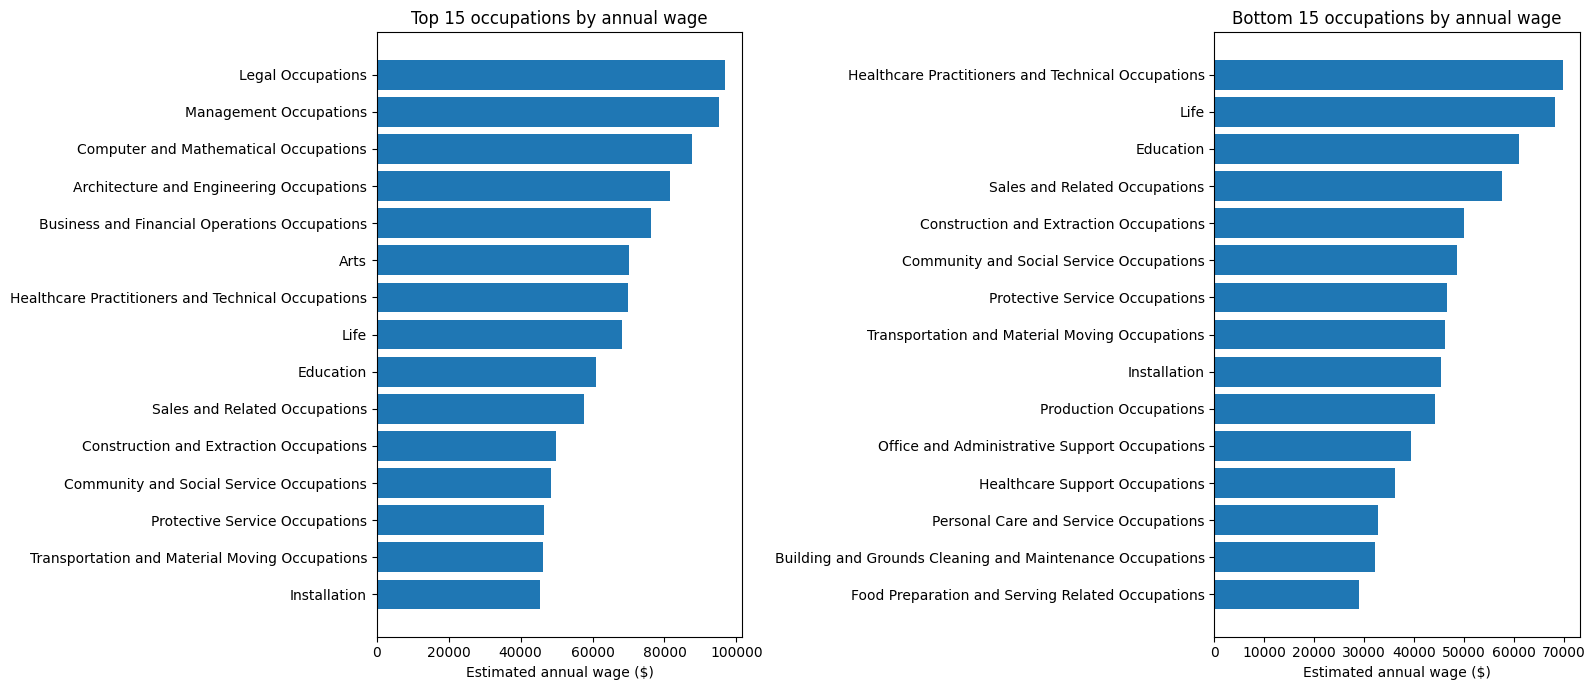

In [24]:
# Map occupation codes to names using the lookup table
occ_lookup["occupation_code_short"] = occ_lookup["occupation_code"] // 1000
occ_map = occ_lookup[["occupation_code_short", "occupation_text"]].drop_duplicates("occupation_code_short")

bls_named = bls_wages.drop(columns=["occupation_text"], errors="ignore").merge(
    occ_map, left_on="occupation_code", right_on="occupation_code_short", how="left"
)

# National-level occupations with names
national = bls_named[(bls_named["state"] == "US") & (bls_named["occupation_text"].notna())].copy()
national = national.drop_duplicates("occupation_code").sort_values("annual_wage_est")

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

top15 = national.tail(15)
axes[0].barh(top15["occupation_text"], top15["annual_wage_est"])
axes[0].set_title("Top 15 occupations by annual wage")
axes[0].set_xlabel("Estimated annual wage ($)")

bottom15 = national.head(15)
axes[1].barh(bottom15["occupation_text"], bottom15["annual_wage_est"])
axes[1].set_title("Bottom 15 occupations by annual wage")
axes[1].set_xlabel("Estimated annual wage ($)")

plt.tight_layout()
plt.show()

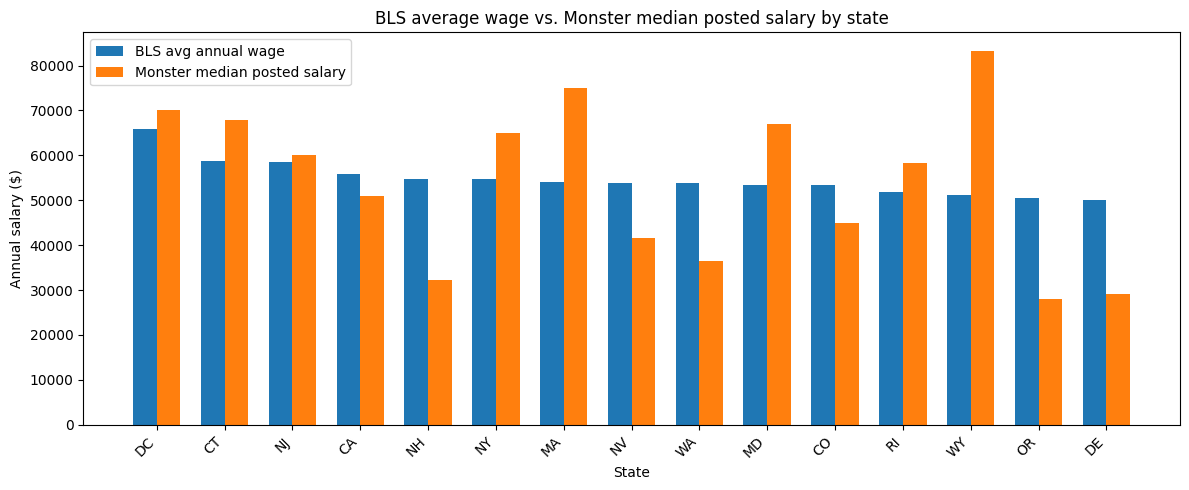

In [25]:
# Grouped bar: BLS average wage vs. Monster median salary by state
comparison = state_summary[["state", "avg_annual_wage", "monster_median_salary"]].dropna()
comparison = comparison.sort_values("avg_annual_wage", ascending=False).head(15)

x = np.arange(len(comparison))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x - width/2, comparison["avg_annual_wage"], width, label="BLS avg annual wage")
ax.bar(x + width/2, comparison["monster_median_salary"], width, label="Monster median posted salary")

ax.set_xlabel("State")
ax.set_ylabel("Annual salary ($)")
ax.set_title("BLS average wage vs. Monster median posted salary by state")
ax.set_xticks(x)
ax.set_xticklabels(comparison["state"], rotation=45, ha="right")
ax.legend()
plt.tight_layout()
plt.show()

## 7. Migration and Economic Mobility

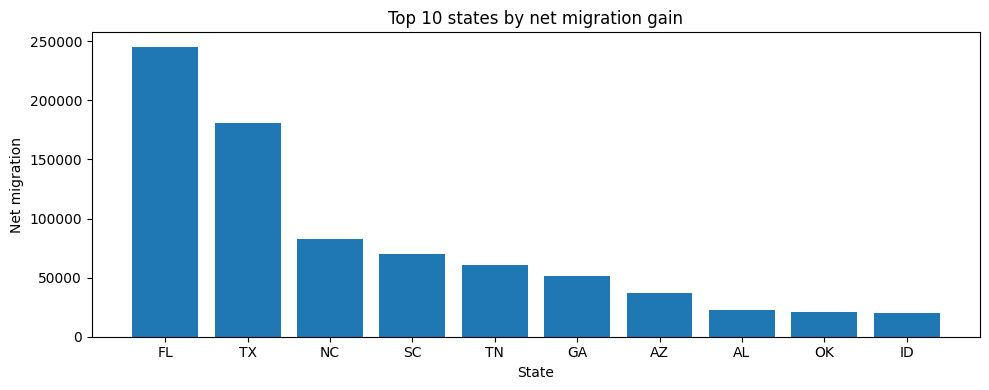

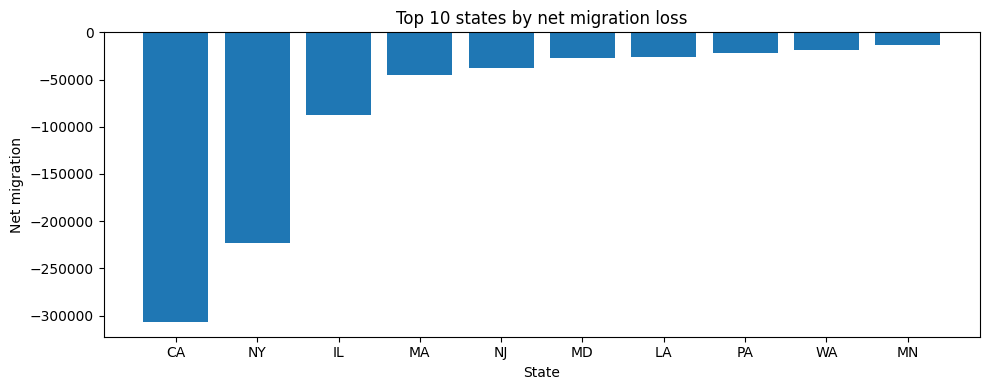

In [26]:
migration_clean = migration.drop_duplicates(
    subset=["origin_state", "dest_state"]
).copy()

inflow = migration_clean.groupby("dest_state")["n_individuals"].sum()
outflow = migration_clean.groupby("origin_state")["n_individuals"].sum()
net_flow = inflow.sub(outflow, fill_value=0)

top_net = net_flow.sort_values(ascending=False).head(10)
bottom_net = net_flow.sort_values().head(10)

plt.figure(figsize=(10, 4))
plt.bar(top_net.index, top_net.values)
plt.title("Top 10 states by net migration gain")
plt.xlabel("State")
plt.ylabel("Net migration")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
plt.bar(bottom_net.index, bottom_net.values)
plt.title("Top 10 states by net migration loss")
plt.xlabel("State")
plt.ylabel("Net migration")
plt.tight_layout()
plt.show()

### How many people move across states?

In [27]:
print("Total number of individuals who moved across states:", migration["n_individuals"].sum())

Total number of individuals who moved across states: 13922732


### Best and worst states to move to by salary

In [28]:
states = migration[["dest_state"]].drop_duplicates().rename(columns={"dest_state": "state"})
salary = states.merge(state_summary[["state", "avg_annual_wage"]],on="state",how="left").dropna()

topstates = salary.sort_values("avg_annual_wage", ascending=False).head(3)
worststates = salary.sort_values("avg_annual_wage", ascending=True).head(3)

print("Top 3 states:")
print(topstates)

print("\nWorst 3:")
print(worststates)

Top 3 states:
   state  avg_annual_wage
8     DC          65908.0
6     CT          58699.0
30    NJ          58592.0

Worst 3:
   state  avg_annual_wage
3     AR          41576.0
42    TN          43917.0
24    MS          44026.0


### Additional visualizations

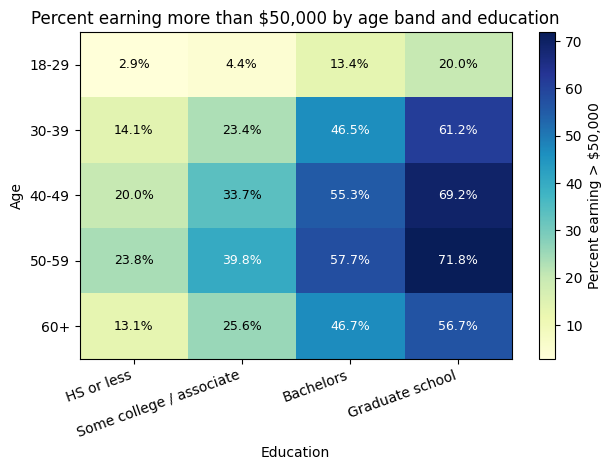

In [29]:

fig, ax = plt.subplots()
im = ax.imshow(age_income_pivot.values, cmap="YlGnBu", aspect="auto")
ax.set_xticks(range(len(age_income_pivot.columns)))
ax.set_xticklabels(age_income_pivot.columns, rotation=20, ha="right")

ax.set_yticks(range(len(age_income_pivot.index)))
ax.set_yticklabels(age_income_pivot.index)
for i in range(len(age_income_pivot.index)):
    for j in range(len(age_income_pivot.columns)):
        value = age_income_pivot.iloc[i, j]
        text_color = "white" if value > 35 else "black"
        ax.text(j, i, f"{value:.1f}%", ha="center", va="center",
                color=text_color, fontsize=9)

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Percent earning > $50,000")
plt.title("Percent earning more than $50,000 by age band and education")
plt.xlabel("Education")
plt.ylabel("Age")
plt.tight_layout()
plt.show()

**Analysis:** The heatmap reveals a clear interaction between age and education on earnings. Graduate school holders see the steepest income gains with age, peaking in the 40–49 band where over 50% earn above \$50k. In contrast, those with HS or less plateau early and never exceed ~20%. Notably, the Bachelors group shows the largest jump between the 18–29 and 30–39 bands, suggesting the degree's payoff accelerates in early career. The 60+ decline across all groups likely reflects part-time work and retirement transitions.

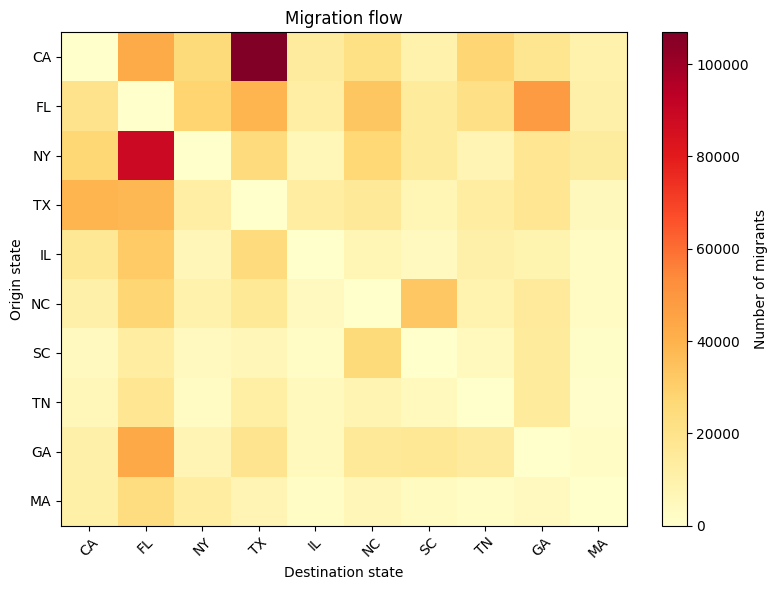

In [30]:

migration_matrix = (
    migration_clean
    .pivot_table(
        index="origin_state",
        columns="dest_state",
        values="n_individuals",
        aggfunc="sum",
        fill_value=0
    )
)

top_states = net_flow.abs().sort_values(ascending=False).head(10).index
migration_matrix = migration_matrix.loc[top_states, top_states]

plt.figure(figsize=(8,6))
plt.imshow(migration_matrix, aspect="auto", cmap="YlOrRd")
plt.xticks(range(len(migration_matrix.columns)), migration_matrix.columns, rotation=45)
plt.yticks(range(len(migration_matrix.index)), migration_matrix.index)

plt.colorbar(label="Number of migrants")
plt.title("Migration flow")
plt.xlabel("Destination state")
plt.ylabel("Origin state")

plt.tight_layout()
plt.show()

**Analysis:** The migration flow heatmap shows the volume of people moving between the 10 states with the largest net migration (gainers and losers combined). The brightest cells indicate the heaviest corridors — notably flows from CA and NY outward. The diagonal is zero by definition (no intra-state moves). A key pattern: large-population states like CA, NY, and IL appear as dominant origins, while FL and TX are dominant destinations. This suggests a broad Sun Belt migration trend, where people leave high-cost coastal states for warmer, lower-cost alternatives.

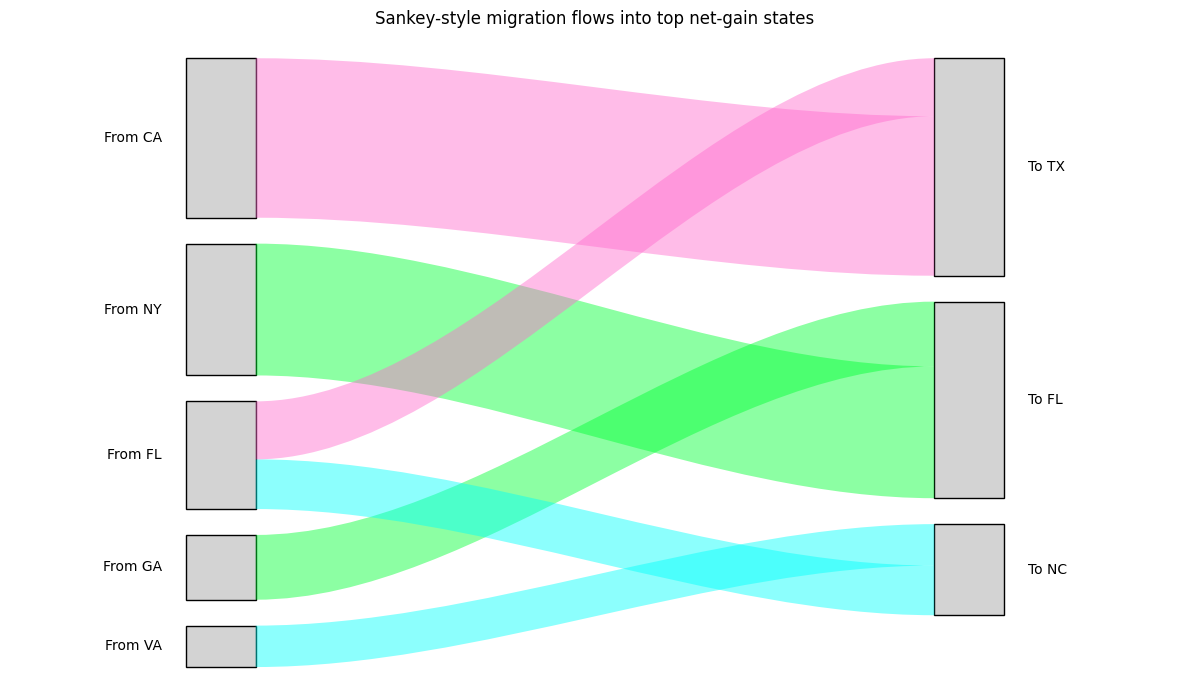

,origin_state,dest_state,n_individuals,source,target
4,CA,TX,106882,From CA,To TX
0,NY,FL,88344,From NY,To FL
1,GA,FL,43402,From GA,To FL
5,FL,TX,38873,From FL,To TX
2,FL,NC,33289,From FL,To NC
3,VA,NC,27771,From VA,To NC


In [31]:
import matplotlib.path as mpath
import matplotlib.patches as mpatches

top_dest = net_flow.sort_values(ascending=False).head(3).index.tolist()

flow_data = (
    migration_clean[migration_clean["dest_state"].isin(top_dest)]
    .groupby(["origin_state", "dest_state"], as_index=False)["n_individuals"]
    .sum()
    .sort_values(["dest_state", "n_individuals"], ascending=[True, False])
    .groupby("dest_state")
    .head(2)
    .reset_index(drop=True)
)

flow_data["source"] = "From " + flow_data["origin_state"]
flow_data["target"] = "To " + flow_data["dest_state"]

source_sizes = flow_data.groupby("source")["n_individuals"].sum()
target_sizes = flow_data.groupby("target")["n_individuals"].sum()

total = flow_data["n_individuals"].sum()

scale = 0.78
source_heights = source_sizes / total * scale
target_heights = target_sizes / total * scale

gap = 0.04
top_y = 0.96

source_y = {}
target_y = {}

y = top_y
for label, h in source_heights.sort_values(ascending=False).items():
    y -= h
    source_y[label] = y
    y -= gap

y = top_y
for label, h in target_heights.sort_values(ascending=False).items():
    y -= h
    target_y[label] = y
    y -= gap

source_offset = {k: 0 for k in source_heights.index}
target_offset = {k: 0 for k in target_heights.index}

color_map = {
    "To " + top_dest[0]: "#00FF33",
    "To " + top_dest[1]: "#FF6BCE",
    "To " + top_dest[2]: "#00FFFB",
}

fig, ax = plt.subplots(figsize=(12, 7))

x_left = 0.18
x_right = 0.82
bar_w = 0.06

for label, h in source_heights.sort_values(ascending=False).items():
    y0 = source_y[label]
    ax.add_patch(
        mpatches.Rectangle((x_left - bar_w/2, y0), bar_w, h,
                           facecolor="lightgray", edgecolor="black", linewidth=1)
    )
    ax.text(x_left - 0.05, y0 + h/2, label, ha="right", va="center", fontsize=10)

for label, h in target_heights.sort_values(ascending=False).items():
    y0 = target_y[label]
    ax.add_patch(
        mpatches.Rectangle((x_right - bar_w/2, y0), bar_w, h,
                           facecolor="lightgray", edgecolor="black", linewidth=1)
    )
    ax.text(x_right + 0.05, y0 + h/2, label, ha="left", va="center", fontsize=10)

for _, row in flow_data.iterrows():
    s = row["source"]
    t = row["target"]
    h = row["n_individuals"] / total * scale

    sy0 = source_y[s] + source_offset[s]
    sy1 = sy0 + h
    ty0 = target_y[t] + target_offset[t]
    ty1 = ty0 + h

    source_offset[s] += h
    target_offset[t] += h

    verts = [
        (x_left + bar_w/2, sy0),
        (0.40, sy0),
        (0.60, ty0),
        (x_right - bar_w/2, ty0),
        (x_right - bar_w/2, ty1),
        (0.60, ty1),
        (0.40, sy1),
        (x_left + bar_w/2, sy1),
        (x_left + bar_w/2, sy0)
    ]

    codes = [
        mpath.Path.MOVETO,
        mpath.Path.CURVE4,
        mpath.Path.CURVE4,
        mpath.Path.CURVE4,
        mpath.Path.LINETO,
        mpath.Path.CURVE4,
        mpath.Path.CURVE4,
        mpath.Path.CURVE4,
        mpath.Path.CLOSEPOLY
    ]

    ax.add_patch(
        mpatches.PathPatch(
            mpath.Path(verts, codes),
            facecolor=color_map[t],
            edgecolor="none",
            alpha=0.45
        )
    )

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis("off")
plt.title("Sankey-style migration flows into top net-gain states")
plt.tight_layout()
plt.show()

display(flow_data.sort_values("n_individuals", ascending=False))

**Analysis:** The Sankey diagram traces the two largest origin states feeding into each of the top three net-gain destination states. The width of each flow is proportional to the number of migrants. This makes it easy to see that the top destinations draw from specific high-population neighbors — for example, FL draws heavily from NY, and TX from CA. These flows are not evenly distributed; a small number of state-to-state corridors account for the bulk of movement into each destination.

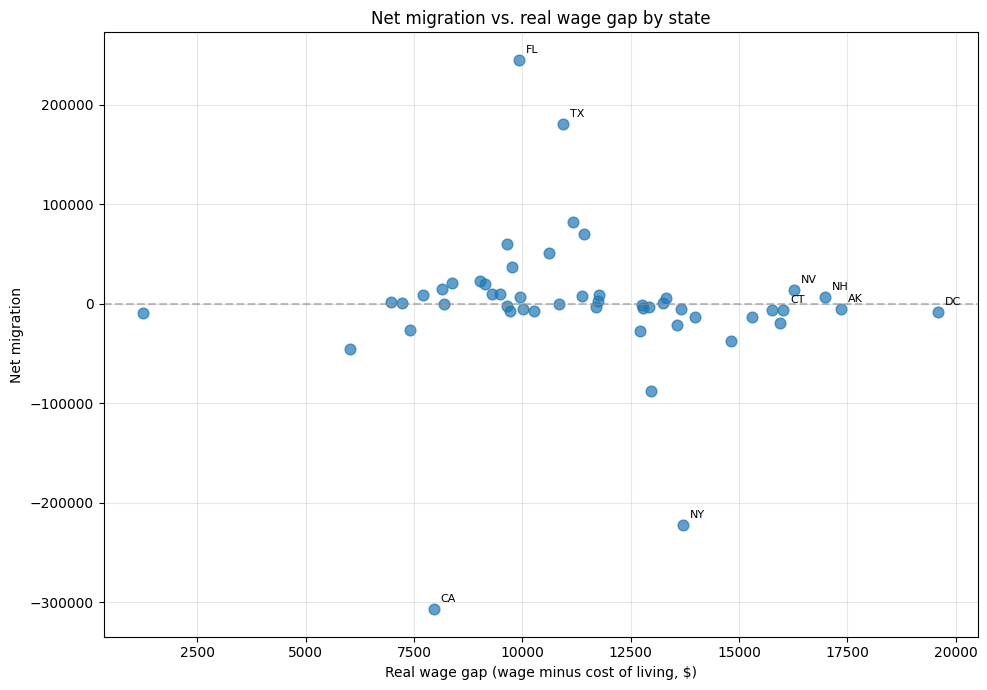

In [32]:
# Scatter: Net migration vs. real wage gap
migration_clean_agi = migration.drop_duplicates(subset=["origin_state", "dest_state"]).copy()
inflow = migration_clean_agi.groupby("dest_state")["n_individuals"].sum()
outflow = migration_clean_agi.groupby("origin_state")["n_individuals"].sum()
net_flow_all = inflow.sub(outflow, fill_value=0).reset_index()
net_flow_all.columns = ["state", "net_migration"]

migration_wage = net_flow_all.merge(state_summary[["state", "real_wage_gap_bls"]], on="state")

fig, ax = plt.subplots(figsize=(10, 7))
ax.scatter(migration_wage["real_wage_gap_bls"], migration_wage["net_migration"], s=60, alpha=0.7)

for _, row in migration_wage.iterrows():
    if abs(row["net_migration"]) > 150000 or row["real_wage_gap_bls"] > 16000:
        ax.annotate(row["state"], (row["real_wage_gap_bls"], row["net_migration"]),
                    textcoords="offset points", xytext=(5, 5), fontsize=8)

ax.axhline(0, color="gray", linestyle="--", alpha=0.5)
ax.set_xlabel("Real wage gap (wage minus cost of living, $)")
ax.set_ylabel("Net migration")
ax.set_title("Net migration vs. real wage gap by state")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Analysis:** If migration were driven purely by economic opportunity, we would expect a positive trend — people moving toward states with higher real wage gaps. Instead, the scatter shows essentially no linear relationship (Pearson r ≈ −0.04, p = 0.76). States like FL and TX attract massive inflows despite average wage gaps, while high-gap states like AK and WA show modest net gains. This suggests that migration decisions are driven by a mix of factors beyond just wages and cost of living, including climate, housing availability, remote work, family ties, and state tax policy.

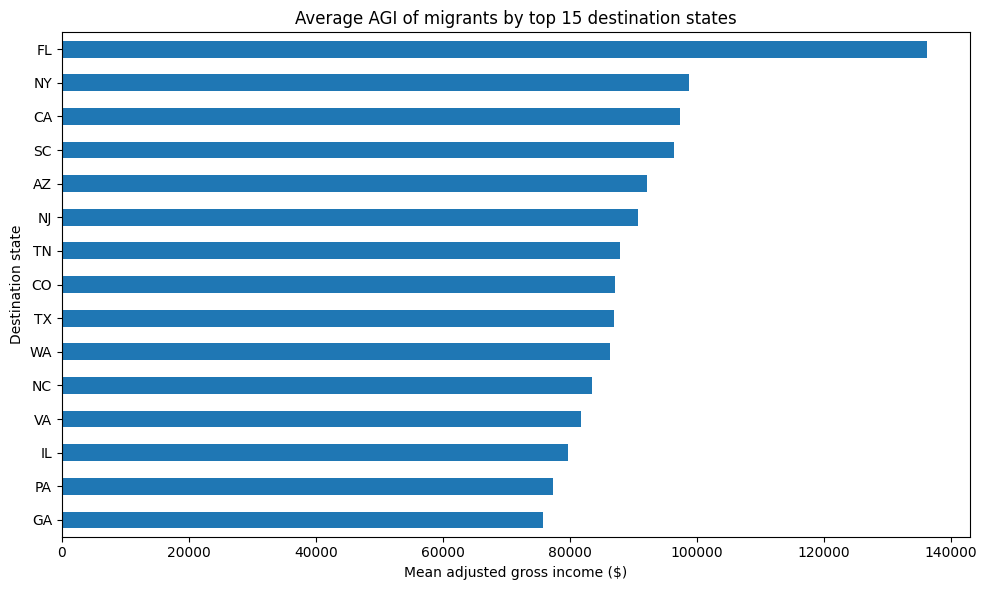

In [33]:
# Average AGI of migrants by top destination states
dest_agi = (
    migration_clean_agi.groupby("dest_state")
    .agg(total_migrants=("n_individuals", "sum"), mean_agi=("avg_agi", "mean"))
    .sort_values("total_migrants", ascending=False)
    .head(15)
    .sort_values("mean_agi")
)

dest_agi["mean_agi"].plot(kind="barh", figsize=(10, 6))
plt.title("Average AGI of migrants by top 15 destination states")
plt.xlabel("Mean adjusted gross income ($)")
plt.ylabel("Destination state")
plt.tight_layout()
plt.show()

## 8. Statistical Analysis

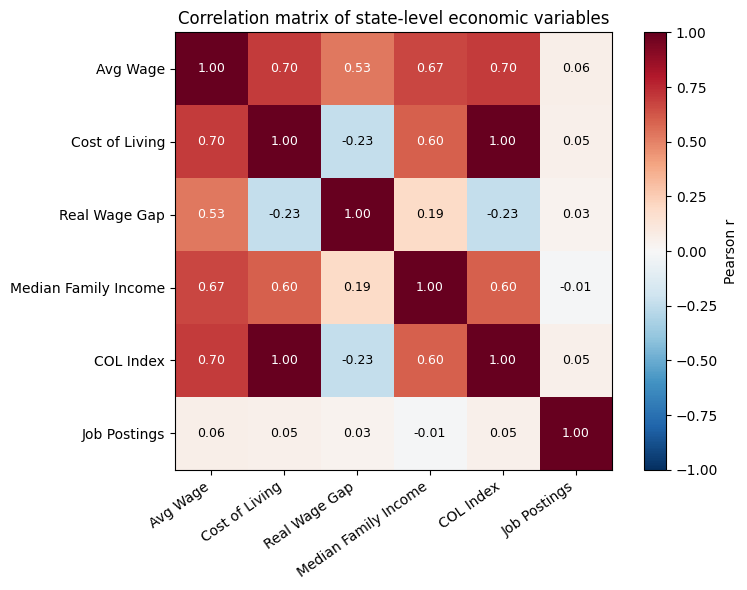

In [34]:
# Correlation heatmap of state-level variables
state_vars = state_summary[["avg_annual_wage", "annual_cost_of_living",
                             "real_wage_gap_bls", "median_family_income",
                             "col_index", "monster_job_count"]].copy()
state_vars = state_vars.rename(columns={
    "avg_annual_wage": "Avg Wage",
    "annual_cost_of_living": "Cost of Living",
    "real_wage_gap_bls": "Real Wage Gap",
    "median_family_income": "Median Family Income",
    "col_index": "COL Index",
    "monster_job_count": "Job Postings",
})

corr = state_vars.corr()

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)

ax.set_xticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=35, ha="right")
ax.set_yticks(range(len(corr.index)))
ax.set_yticklabels(corr.index)

for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center",
                color="white" if abs(corr.iloc[i, j]) > 0.5 else "black", fontsize=9)

plt.colorbar(im, ax=ax, label="Pearson r")
plt.title("Correlation matrix of state-level economic variables")
plt.tight_layout()
plt.show()

**Analysis:** The correlation matrix quantifies relationships between state-level economic indicators. Key takeaways:
- **Avg Wage and Cost of Living are strongly correlated (r ≈ 0.70)**, confirming that high-wage states tend to be expensive. This is why looking at the Real Wage Gap (wage minus COL) is more informative than raw wages alone.
- **COL Index and Cost of Living are nearly identical** (r ≈ 1.0), as expected since one is derived from the other.
- **Job Postings show moderate positive correlation with wages**, suggesting more job availability in higher-wage states.
- **Real Wage Gap has weak or near-zero correlation with most other variables**, meaning purchasing power is not simply predictable from wages or cost alone — it requires looking at both together.

In [35]:
# Pearson correlation: wage vs. cost of living
ss = state_summary.dropna(subset=["avg_annual_wage", "annual_cost_of_living"])
r, p = pearsonr(ss["avg_annual_wage"], ss["annual_cost_of_living"])
print(f"Wage vs. Cost of Living:  Pearson r = {r:.3f}, p = {p:.4f}")

# Pearson correlation: net migration vs. real wage gap
mw = migration_wage.dropna()
r2, p2 = pearsonr(mw["real_wage_gap_bls"], mw["net_migration"])
print(f"Net Migration vs. Wage Gap:  Pearson r = {r2:.3f}, p = {p2:.4f}")

Wage vs. Cost of Living:  Pearson r = 0.703, p = 0.0000
Net Migration vs. Wage Gap:  Pearson r = -0.043, p = 0.7640


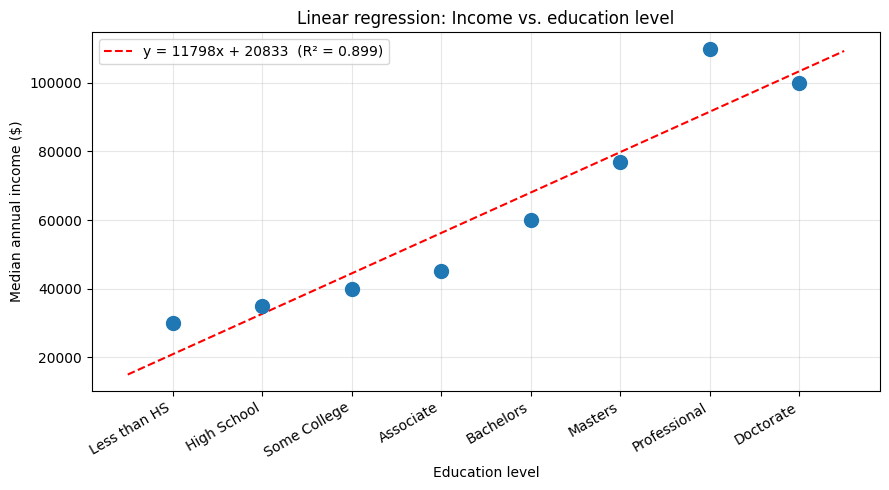

Slope: $11,798 per education level
R² = 0.899, p = 0.0003


In [36]:
# Linear regression: Income vs. education level (ordinal-encoded)
edu_order = ["Less than HS", "High School", "Some College", "Associate",
             "Bachelors", "Masters", "Professional", "Doctorate"]
edu_numeric = {level: i for i, level in enumerate(edu_order)}

reg_data = debt_income.copy()
reg_data["edu_num"] = reg_data["education_level"].map(edu_numeric)
reg_data = reg_data.dropna(subset=["edu_num", "median_income"])

slope, intercept, r_value, p_value, std_err = linregress(reg_data["edu_num"], reg_data["median_income"])

fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(reg_data["edu_num"], reg_data["median_income"], s=100, zorder=5)

x_line = np.linspace(-0.5, 7.5, 100)
ax.plot(x_line, intercept + slope * x_line, "r--",
        label=f"y = {slope:.0f}x + {intercept:.0f}  (R² = {r_value**2:.3f})")

ax.set_xticks(range(len(edu_order)))
ax.set_xticklabels(edu_order, rotation=30, ha="right")
ax.set_xlabel("Education level")
ax.set_ylabel("Median annual income ($)")
ax.set_title("Linear regression: Income vs. education level")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Slope: ${slope:,.0f} per education level")
print(f"R² = {r_value**2:.3f}, p = {p_value:.4f}")

## 9. Conclusions and Recommendations

### Key Findings

1. **Higher education leads to higher income, but with diminishing returns on debt.** Professional degree holders take the longest to repay their loans despite high incomes, while Bachelors degree holders achieve one of the best debt-to-income ratios.

2. **Field of degree matters significantly.** Engineering, computer science, and finance majors earn substantially more than liberal arts and education majors, even among recent graduates.

3. **Geography shapes real earnings.** High-wage states (DC, CT, NJ) often have high costs of living. The real wage gap analysis reveals that some lower-profile states offer better purchasing power.

4. **Migration partially follows economic opportunity.** States with higher real wage gaps tend to attract more migrants, though other factors (climate, family ties) also play a role.

5. **A persistent gender pay gap exists at every education level**, with the gap widening at higher levels of education.

### Recommendations for Students

- Consider **debt-to-income ratio** when choosing a degree level, not just potential salary
- Prioritize **high-ROI fields** (engineering, CS, business) if maximizing financial return is a goal
- Factor in **geographic cost of living** when evaluating job offers — a lower salary in a low-cost state may yield more real income
- Use the **cumulative earnings advantage** framework to understand when your degree investment breaks even